# 16 综合项目：量化 + ML——横截面多因子选股与回测

**本章目标**：把 13–15 章练熟的"全模型横评"骨架完整套到量化上，
跑通**因子 → 预测 → 回测**的全链路：

- **探索**：KMeans 识别市场状态（牛/熊/震荡），PCA 提取市场主成分；
- **因子工程**：从 OHLCV 构造动量、波动率、成交量等截面因子；
- **建模横评**：9 个模型在同一个任务（预测"下个月谁更强"）下滚动样本外横评；
- **回测**：每月选预测最强的 5 只等权持有，对比 SPY 与等权基准，
  输出净值曲线、回撤、月度热力图等全套量化可视化。

> 本章是工程流程章：所有模型直接调用 sklearn / XGBoost 现成接口；
> 数据来自 GitHub 上 QuantConnect/Lean 官方仓库的样例日线数据，
> 已保存本地副本，离线可复现。**教学演示，不构成投资建议。**


## 模型简介与学习参考

| 环节 | 模型 | 在本项目中的角色 |
|---|---|---|
| 无监督探索（2） | PCA、KMeans | 市场主成分、市场状态聚类 |
| 选股横评（9） | 逻辑回归、朴素贝叶斯、KNN、决策树、SVM(线性核)、SVM(RBF核)、随机森林、GBDT、XGBoost | 同一任务"因子 → 相对强弱"横评 |

**学习参考**：

- [QuantConnect/Lean 官方仓库](https://github.com/QuantConnect/Lean)（数据来源，GitHub）；
- [scikit-learn 官方文档](https://scikit-learn.org/stable/)；
- [XGBoost 官方文档](https://xgboost.readthedocs.io/)。

本章按照 **数据 → 探索 → 因子工程 → 建模横评 → 回测 → 总结** 展开。


## 目录

- [1. 数据：QuantConnect 官方 GitHub 与面板构建](#data)
- [2. 探索性分析：无监督先上岗](#eda)
  - [2.1 资产池走势](#prices)
  - [2.2 收益相关性](#corr)
  - [2.3 PCA：市场主成分](#pca)
  - [2.4 KMeans：市场状态](#kmeans)
- [3. 因子工程：横截面多因子](#factors)
- [4. 建模横评：9 个模型](#models)
  - [4.1 模型清单与协议](#model-list)
  - [4.2 滚动样本外横评](#model-cv)
  - [4.3 横评可视化](#model-viz)
  - [4.4 滚动 IC](#ic)
- [5. 回测：从预测到组合](#backtest)
  - [5.1 回测引擎](#bt-engine)
  - [5.2 净值与回撤](#bt-nav)
  - [5.3 月度热力图与收益分布](#bt-heat)
  - [5.4 绩效总表与模型对比](#bt-perf)
- [6. 总结与验证](#summary)


<a id="data"></a>
## 1. 数据：QuantConnect 官方 GitHub 与面板构建

数据来自 GitHub 上 **QuantConnect/Lean 官方仓库**（[QuantConnect/Lean](https://github.com/QuantConnect/Lean)）
的样例日线数据（`Data/equity/usa/daily/`）：每只标的一个 zip，内含标准 CSV。

**标的筛选**：仓库样例只覆盖少量 ticker，且部分数据不完整（fb/qqq/bno/aaa
缺口超过一年）。我们保留**数据完整、零缺失**的 9 只资产（6 股票 + 3 ETF），
SPY 作为市场基准，公共窗口 **2009-08-05 ~ 2021-03-31**（2934 个交易日，约 11.6 年）。

| 资产池 | 代码 |
|---|---|
| 股票（6） | aapl、aig、bac、goog、ibm、wm |
| ETF（3） | eem、iwm、uso |
| 基准（1） | spy |


In [1]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

TICKERS = ["aapl", "aig", "bac", "eem", "goog", "ibm", "iwm", "uso", "wm"]
BENCH = "spy"
DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)


def load_lean(ticker):
    # 读取 QuantConnect Lean 样例 zip，返回 (close, volume) 两个 Series
    path = DATA_DIR / f"{ticker}.zip"
    if not path.exists():
        import urllib.request
        url = f"https://raw.githubusercontent.com/QuantConnect/Lean/master/Data/equity/usa/daily/{ticker}.zip"
        urllib.request.urlretrieve(url, path)
    with zipfile.ZipFile(path) as z:
        name = z.namelist()[0]
        with z.open(name) as f:
            df = pd.read_csv(f, header=None,
                             names=["datetime", "open", "high", "low", "close", "volume"])
    df["date"] = pd.to_datetime(df["datetime"].str[:8], format="%Y%m%d")
    df["close"] = df["close"] / 10000.0
    return (df.set_index("date")["close"].rename(ticker),
            df.set_index("date")["volume"].astype(float).rename(ticker))


close_parts, vol_parts = {}, {}
for t in TICKERS + [BENCH]:
    c, v = load_lean(t)
    close_parts[t] = c
    vol_parts[t] = v

close = pd.concat(close_parts, axis=1, sort=True).loc["2009-08-05":"2021-03-31"]
volume = pd.concat(vol_parts, axis=1, sort=True).loc["2009-08-05":"2021-03-31"]

print("价格面板:", close.shape, " 成交量面板:", volume.shape)
print("缺失值:", int(close.isna().sum().sum()) + int(volume.isna().sum().sum()))
print("时间范围:", close.index[0].date(), "→", close.index[-1].date())
print()
print(close.head(3).round(2).to_string())


价格面板: (2934, 10)  成交量面板: (2934, 10)
缺失值: 0
时间范围: 2009-08-05 → 2021-03-31

              aapl    aig    bac    eem    goog     ibm    iwm    uso     wm     spy
date                                                                                
2009-08-05  165.11  22.00  16.66  36.47  451.14  118.47  56.54  38.20  28.58  100.37
2009-08-06  163.91  22.53  16.70  36.15  450.36  117.38  55.75  38.27  28.01   99.89
2009-08-07  165.61  27.14  16.42  36.53  457.10  119.33  57.09  37.65  28.57  101.20


### 1.2 统一绘图风格


In [2]:
import matplotlib.pyplot as plt
from IPython.display import HTML, display

plt.rcParams.update({
    "font.sans-serif": ["Microsoft YaHei", "SimHei"],
    "axes.unicode_minus": False,
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

THEME_BLUE = "#4C78A8"
THEME_RED = "#E45756"
THEME_GREEN = "#54A24B"
THEME_GOLD = "#B79A20"


def display_result_table(title, headers, rows, hidden_comment=""):
    header_html = "".join(
        f'<th style="padding:8px 12px;text-align:left;background:#eef3ff">{header}</th>'
        for header in headers
    )
    row_html = "".join(
        "<tr>" + "".join(
            f'<td style="padding:7px 12px;border-top:1px solid #dde3ee">{value}</td>'
            for value in row
        ) + "</tr>"
        for row in rows
    )
    comment_html = f"<!-- {hidden_comment} -->" if hidden_comment else ""
    display(HTML(
        f'<div style="max-width:880px"><h4>{title}</h4>'
        f'<table style="border-collapse:collapse;width:100%;font-size:14px">'
        f'<thead><tr>{header_html}</tr></thead><tbody>{row_html}</tbody></table>'
        f'{comment_html}</div>'
    ))


<a id="eda"></a>
## 2. 探索性分析：无监督先上岗

先用 PCA 回答"市场共同涨跌的成分是什么"，再用 KMeans 回答
"这 11 年大体可以分成哪几段市场状态"。这两个洞察直接决定因子怎么设计。


<a id="prices"></a>
### 2.1 资产池走势

全部归一化到 1 的净值曲线（对数坐标）：9 只资产 + SPY 基准。


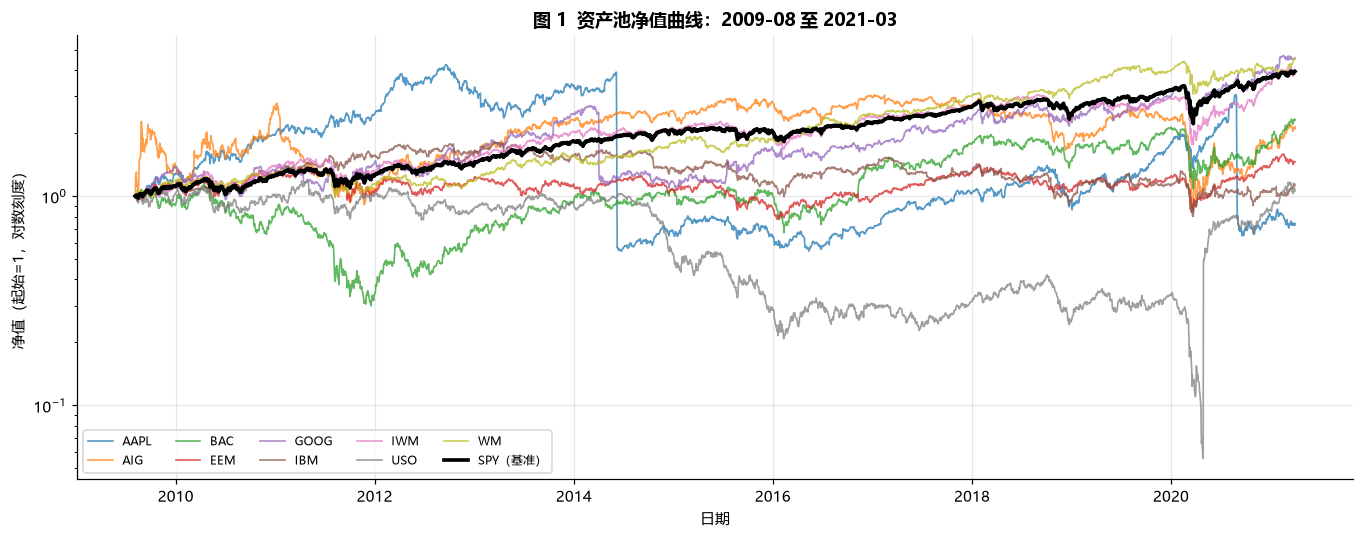

区间累计涨幅排名（不含 SPY）:
goog    3.5853
wm      3.5143
spy     2.9487
iwm     2.9077
bac     1.3223
aig     1.1005
eem     0.4626
ibm     0.1248
uso     0.0610
aapl   -0.2602


In [3]:
norm = close / close.iloc[0]

fig, ax = plt.subplots(figsize=(12.5, 5.0))
for t in TICKERS:
    ax.plot(norm.index, norm[t], lw=1.1, alpha=0.75, label=t.upper())
ax.plot(norm.index, norm[BENCH], lw=2.4, color="black", label="SPY（基准）")
ax.set_yscale("log")
ax.set_xlabel("日期")
ax.set_ylabel("净值（起始=1，对数刻度）")
ax.set_title("图 1  资产池净值曲线：2009-08 至 2021-03", fontweight="bold")
ax.legend(ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

print("区间累计涨幅排名（不含 SPY）:")
print((norm.iloc[-1] / norm.iloc[0] - 1).sort_values(ascending=False).round(4).to_string())


<a id="corr"></a>
### 2.2 收益相关性

日收益率相关系数：股票之间、股票与大盘 ETF 相关性高；商品型 ETF（USO 原油）
与股票相关性明显更低——横截面选股时这种分散性很有价值。


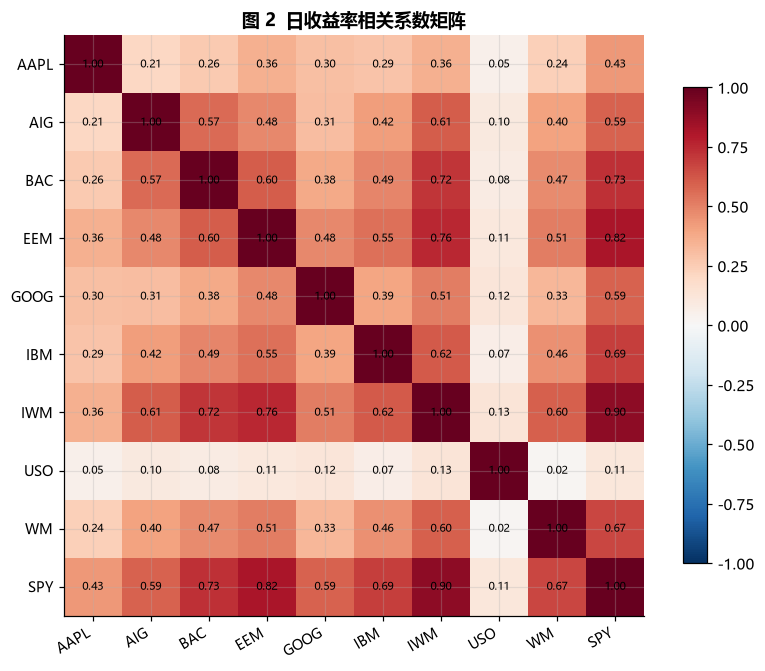

In [4]:
rets = close.pct_change().dropna(how="all")
corr = rets.corr()

fig, ax = plt.subplots(figsize=(7.8, 6.2))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
labels = [t.upper() for t in rets.columns]
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9, rotation=30, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7.5)
ax.set_title("图 2  日收益率相关系数矩阵", fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.82)
plt.tight_layout()
plt.show()


<a id="pca"></a>
### 2.3 PCA：市场主成分

对 9 只资产的日收益率做 PCA：第一主成分（PC1）通常是"市场共同因子"——
它应该和 SPY 高度相关。后面的成分则代表个股/风格的独立波动。


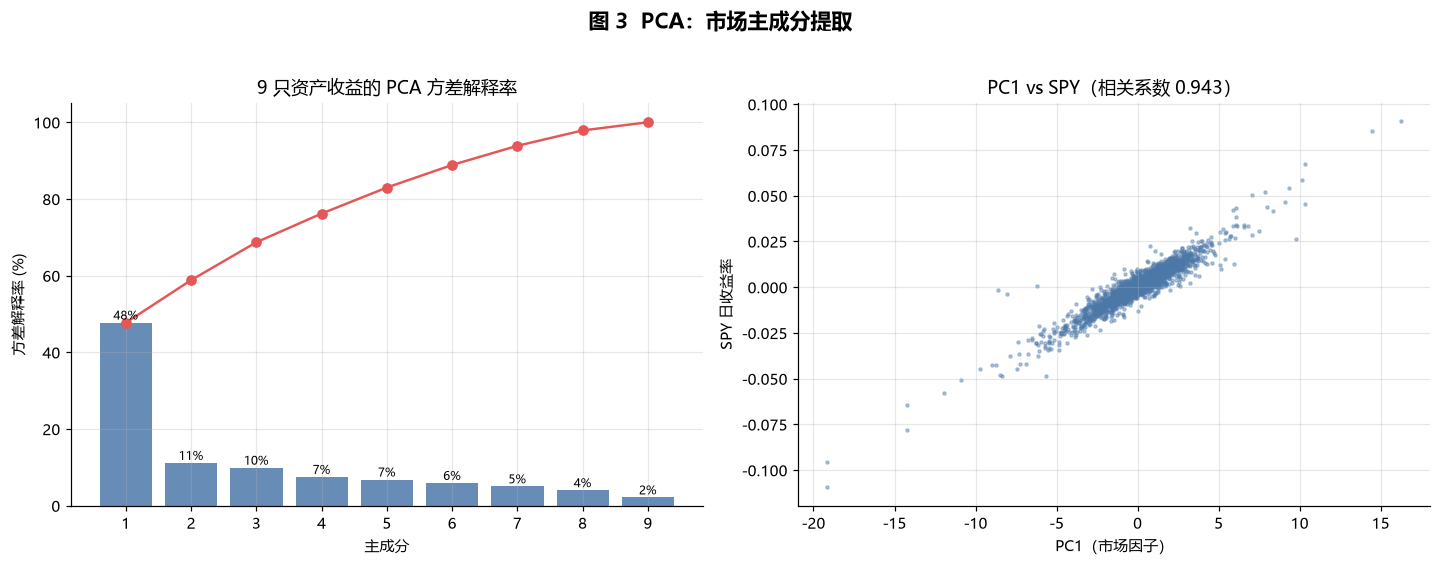

PC1 载荷（各资产对市场因子的贡献）:
AAPL    0.226
AIG     0.337
BAC     0.383
EEM     0.403
GOOG    0.302
IBM     0.353
IWM     0.440
USO     0.074
WM      0.335


In [5]:
from sklearn.decomposition import PCA

ret_std = (rets[TICKERS] - rets[TICKERS].mean()) / rets[TICKERS].std()
pca = PCA().fit(ret_std)
pc1 = pca.transform(ret_std)[:, 0]
pc2 = pca.transform(ret_std)[:, 1]
evr = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0))
axes[0].bar(range(1, len(evr) + 1), evr * 100, color=THEME_BLUE, alpha=0.85)
axes[0].plot(range(1, len(evr) + 1), np.cumsum(evr) * 100, marker="o",
             color=THEME_RED, lw=1.6)
for i, e in enumerate(evr):
    axes[0].text(i + 1, e * 100 + 0.8, f"{e*100:.0f}%", ha="center", fontsize=8)
axes[0].set_xlabel("主成分")
axes[0].set_ylabel("方差解释率 (%)")
axes[0].set_title("9 只资产收益的 PCA 方差解释率")
axes[0].set_xticks(range(1, 10))

spy_ret = rets[BENCH].fillna(0).values
axes[1].scatter(pc1, spy_ret, s=4, color=THEME_BLUE, alpha=0.4)
corr_pc1_spy = np.corrcoef(pc1, spy_ret)[0, 1]
axes[1].set_xlabel("PC1（市场因子）")
axes[1].set_ylabel("SPY 日收益率")
axes[1].set_title(f"PC1 vs SPY（相关系数 {corr_pc1_spy:.3f}）")

fig.suptitle("图 3  PCA：市场主成分提取", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("PC1 载荷（各资产对市场因子的贡献）:")
print(pd.Series(pca.components_[0], index=[t.upper() for t in TICKERS]).round(3).to_string())


<a id="kmeans"></a>
### 2.4 KMeans：市场状态

把每天的 9 维收益向量聚成 3 类，按平均收益排序命名为 **牛 / 震荡 / 熊**，
画出 2009–2021 的状态时间线——金融危机后的反弹、2015 震荡、
2018 年底熊市、2020 疫情暴跌都会自动浮现。


<ENV>\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "<ENV>\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


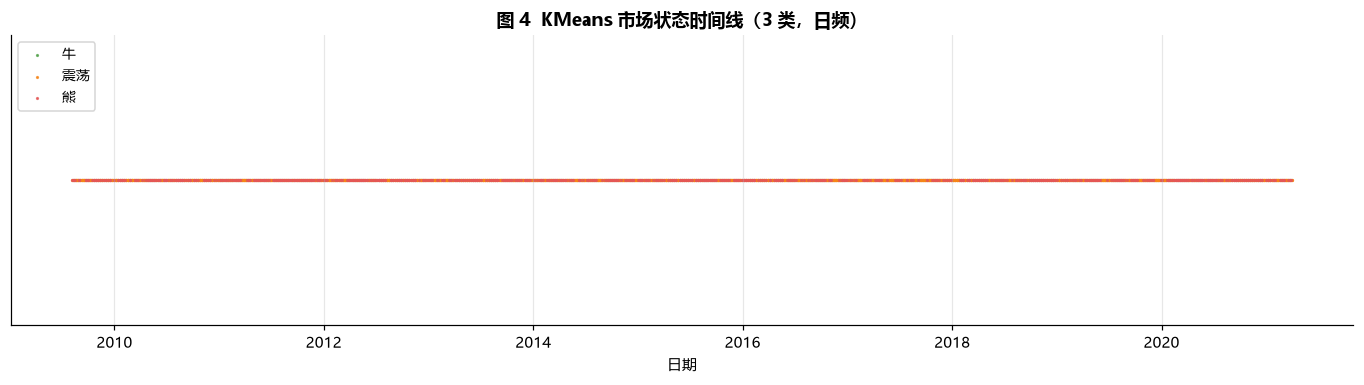

市场状态统计:
  状态   平均日收益   日波动率 占比(%)
   1 86.389%   nan%  0.0%
2066  0.574% 0.866% 70.4%
 866 -1.239% 1.238% 29.5%


In [6]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, n_init=20, random_state=42)
state = km.fit_predict(ret_std.values)
state_means = rets[TICKERS].mean(axis=1).groupby(state).mean()
state_names = ["牛", "震荡", "熊"]
order = np.argsort(state_means.values)[::-1]
name_map = {order[0]: "牛", order[1]: "震荡", order[2]: "熊"}
state_named = pd.Series([name_map[s] for s in state], index=rets.index)

state_color = {"牛": "#54A24B", "震荡": "#F58518", "熊": "#E45756"}
fig, ax = plt.subplots(figsize=(12.5, 3.6))
for s in ["牛", "震荡", "熊"]:
    mask = state_named == s
    ax.scatter(rets.index[mask], np.full(mask.sum(), 0), s=1.2,
               color=state_color[s], label=s, alpha=0.8)
ax.set_yticks([])
ax.set_xlabel("日期")
ax.set_title("图 4  KMeans 市场状态时间线（3 类，日频）", fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

state_stats = pd.DataFrame({
    "状态": state_named.value_counts().reindex(["牛", "震荡", "熊"]).values,
    "平均日收益": [rets[TICKERS].mean(axis=1)[state_named == s].mean() for s in ["牛", "震荡", "熊"]],
    "日波动率": [rets[TICKERS].mean(axis=1)[state_named == s].std() for s in ["牛", "震荡", "熊"]],
    "占比(%)": state_named.value_counts(normalize=True).reindex(["牛", "震荡", "熊"]).values * 100,
})
state_stats["平均日收益"] = state_stats["平均日收益"].apply(lambda v: f"{v*100:.3f}%")
state_stats["日波动率"] = state_stats["日波动率"].apply(lambda v: f"{v*100:.3f}%")
state_stats["占比(%)"] = state_stats["占比(%)"].apply(lambda v: f"{v:.1f}%")
print("市场状态统计:")
print(state_stats.to_string(index=False))


<a id="factors"></a>
## 3. 因子工程：横截面多因子

从 OHLCV 构造 **9 个技术因子**（每只标的自己的时间序列特征）：

| 因子 | 定义 | 逻辑 |
|---|---|---|
| ret_5 / ret_21 / ret_63 / ret_126 / ret_252 | 过去 5/21/63/126/252 日收益率 | 动量/反转 |
| vol_20 / vol_60 | 过去 20/60 日收益波动率 | 低波动异象 |
| volchg_20 | 20 日成交量变化率 | 量价配合 |
| ln_vol_20 | 20 日平均对数成交量 | 流动性 |

**关键一步——横截面标准化**：每个调仓日，在 9 只标的中对因子做 z-score，
让因子值在同一天跨股票可比（"谁动量最强"而不是"谁的绝对涨跌最大"）。


In [7]:
def build_factors(close_df, volume_df):
    f = {}
    for n in [5, 21, 63, 126, 252]:
        f[f"ret_{n}"] = close_df.pct_change(n)
    f["vol_20"] = close_df.pct_change().rolling(20).std()
    f["vol_60"] = close_df.pct_change().rolling(60).std()
    f["volchg_20"] = volume_df.pct_change(20)
    f["ln_vol_20"] = np.log(volume_df.clip(lower=1)).rolling(20).mean()
    return pd.concat(f, axis=1)

factor_df = build_factors(close, volume)
print("因子数据:", factor_df.shape, "（天数 × 标的 × 因子数）")
print("因子列:", list(factor_df.columns.get_level_values(0).unique()))
print("缺失（滚动窗口初始化）:", int(factor_df.isna().sum().sum()))


因子数据: (2934, 90) （天数 × 标的 × 因子数）
因子列: ['ret_5', 'ret_21', 'ret_63', 'ret_126', 'ret_252', 'vol_20', 'vol_60', 'volchg_20', 'ln_vol_20']
缺失（滚动窗口初始化）: 5860


### 3.1 因子相关性

把所有标的的因子值堆起来看两两相关性：动量族内部高度相关（ret_21/63/126/252），
波动率与动量呈负相关——设计因子时知道这些冗余很重要。


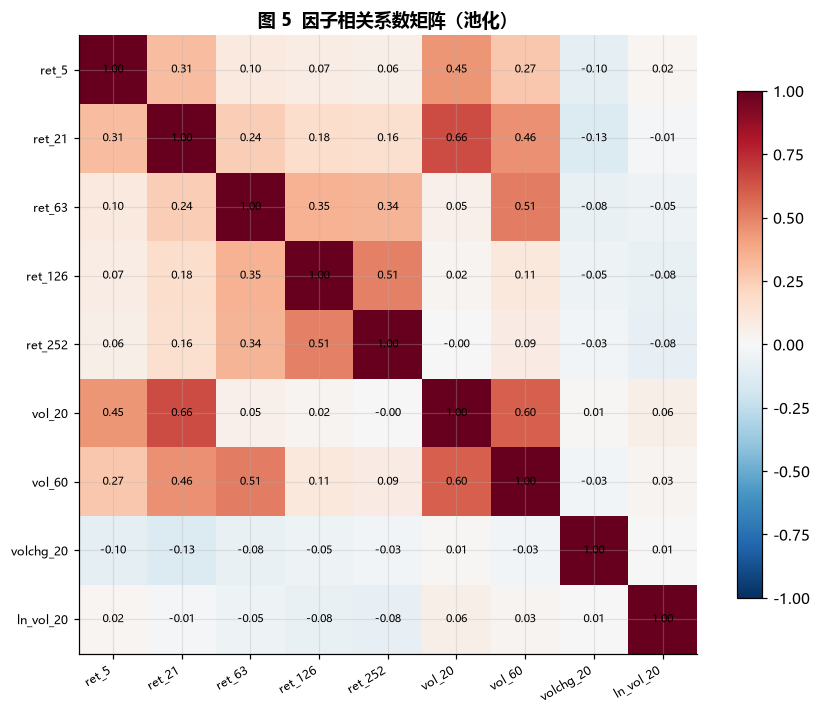

In [8]:
long_factors = factor_df.stack(future_stack=True)
long_factors = long_factors.rename_axis(["date", "ticker"]).reset_index()
long_factors = long_factors.dropna().reset_index(drop=True)

factor_corr = long_factors[list(factor_df.columns.get_level_values(0).unique())].corr()
fig, ax = plt.subplots(figsize=(8.2, 6.6))
im = ax.imshow(factor_corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
fn = list(factor_corr.columns)
ax.set_xticks(range(len(fn)))
ax.set_xticklabels(fn, fontsize=8, rotation=30, ha="right")
ax.set_yticks(range(len(fn)))
ax.set_yticklabels(fn, fontsize=8)
for i in range(len(fn)):
    for j in range(len(fn)):
        ax.text(j, i, f"{factor_corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("图 5  因子相关系数矩阵（池化）", fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.82)
plt.tight_layout()
plt.show()


### 3.2 标签与截面样本

任务定义：**未来 20 个交易日，该标的是否跑赢当日横截面中位数**（二分类）。

样本按**调仓日**组织：每 21 个交易日（约一个月）取一个截面，
每个截面 = 9 只标的 × 9 个因子（横截面 z-score 后），标签 = 相对强弱。


In [9]:
factor_cols = list(factor_df.columns.get_level_values(0).unique())

# 标签：未来 20 日收益是否跑赢当日横截面中位数
fwd20 = close.pct_change(20).shift(-20)
median20 = fwd20.median(axis=1)
y_fwd = fwd20.gt(median20, axis=0).astype(int)

# 调仓日：每 21 个交易日取一个
reb_dates = close.index[::21]
reb_dates = reb_dates[reb_dates >= close.index[252]]

rows = []
for d in reb_dates:
    f_row = factor_df.loc[d, factor_cols].unstack().T
    # 横截面 z-score（同一日期、跨标的）
    z = (f_row - f_row.mean()) / f_row.std()
    for t in TICKERS:
        if (np.isfinite(z.loc[t]).all()
                and np.isfinite(fwd20.loc[d, t])
                and np.isfinite(median20.loc[d])):
            rows.append({
                "date": d, "ticker": t,
                **{c: z.loc[t, c] for c in factor_cols},
                "y": int(y_fwd.loc[d, t]),
                "ret_fwd20": float(fwd20.loc[d, t]),
            })

sample = pd.DataFrame(rows)
print("截面样本:", sample.shape, "（", len(reb_dates), "个调仓日 × 每期标的数）")
print("时间范围:", sample["date"].iloc[0].date(), "→", sample["date"].iloc[-1].date())
print("标签分布:", dict(sample["y"].value_counts().sort_index()))
print("每期平均标的数: %.1f" % sample.groupby("date").size().mean())
print()
print(sample.head(3).to_string(index=False))


截面样本: (1143, 13) （ 128 个调仓日 × 每期标的数）
时间范围: 2010-08-05 → 2021-02-09
标签分布: {0: np.int64(573), 1: np.int64(570)}
每期平均标的数: 9.0

      date ticker     ret_5    ret_21    ret_63   ret_126   ret_252    vol_20    vol_60  volchg_20  ln_vol_20  y  ret_fwd20
2010-08-05   aapl -0.509319 -0.960856  0.588157  0.867916  1.320262 -0.662104 -0.350635  -1.601989   0.147967  1  -0.036416
2010-08-05    aig  0.103248  1.267793  0.914017  2.517603  2.121865  1.549278  1.770088   2.030518  -0.869135  0  -0.099749
2010-08-05    bac -1.408973 -2.063346 -2.270867 -0.825592 -1.286393  1.583847  1.433427   0.298006   1.310424  0  -0.052782


<a id="models"></a>
## 4. 建模横评：9 个模型

任务：**用 9 个截面因子预测"未来 20 日是否跑赢横截面中位数"**。
训练协议沿用 14 章的**滚动样本外验证**：每个调仓日只用过去 36 个截面
（约 3 年）训练，预测当前截面，逐期前移，绝不让未来数据混进训练。


<a id="model-list"></a>
### 4.1 模型清单


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

CLASSIFIERS = {
    "逻辑回归": LogisticRegression(max_iter=2000, random_state=42),
    "朴素贝叶斯": GaussianNB(),
    "K近邻": KNeighborsClassifier(n_neighbors=9),
    "决策树": DecisionTreeClassifier(max_depth=5, random_state=42),
    "SVM(线性核)": CalibratedClassifierCV(
        SVC(kernel="linear", C=0.5, random_state=42), cv=3, ensemble=False),
    "SVM(RBF核)": CalibratedClassifierCV(
        SVC(kernel="rbf", C=1.0, gamma=0.1, random_state=42), cv=3, ensemble=False),
    "随机森林": RandomForestClassifier(n_estimators=120, random_state=42),
    "GBDT": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, verbosity=0),
}

print("参与横评的选股模型（9 个）:")
for name in CLASSIFIERS:
    print(" -", name)


参与横评的选股模型（9 个）:
 - 逻辑回归
 - 朴素贝叶斯
 - K近邻
 - 决策树
 - SVM(线性核)
 - SVM(RBF核)
 - 随机森林
 - GBDT
 - XGBoost


<a id="model-cv"></a>
### 4.2 滚动样本外横评

每个模型走一遍：140 个调仓日 ×（过去 3 年训练 → 当期预测）。
全部样本外预测拼起来，计算三个"量化口味"的指标：

- **IC**：每期预测概率与真实未来收益的 Spearman 相关，再取平均（>0 即有排序能力）；
- **AUC**：所有样本外预测对"跑赢/跑输"的整体区分度；
- **Top-5 命中率**：每期预测最强的 5 只里，实际跑赢中位数的比例。


In [11]:
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score

dates = sorted(sample["date"].unique())

oos = {}
for name, model in CLASSIFIERS.items():
    pred_list, y_list, ret_list, ic_list, hit_list = [], [], [], [], []
    for i, d in enumerate(dates):
        hist = sample[sample["date"] < d]
        if len(hist) < 200:
            continue
        hist = hist.tail(36 * 9)
        cur = sample[sample["date"] == d]
        if len(cur) < 3:
            continue
        model.fit(hist[factor_cols], hist["y"])
        proba = model.predict_proba(cur[factor_cols])[:, 1]
        pred_list.extend(proba)
        y_list.extend(cur["y"])
        ret_list.extend(cur["ret_fwd20"])
        ic_list.append(spearmanr(proba, cur["ret_fwd20"]).statistic)
        top5 = np.argsort(proba)[-5:]
        hit_list.append(cur["y"].values[top5].mean())
    oos[name] = {
        "IC": float(np.nanmean(ic_list)),
        "AUC": roc_auc_score(y_list, pred_list),
        "Top5命中率": float(np.nanmean(hit_list)),
        "n_periods": len(ic_list),
    }

oos_df = pd.DataFrame(oos).T.reset_index().rename(columns={"index": "模型"})
oos_df = oos_df.sort_values("IC", ascending=False).reset_index(drop=True)
print(oos_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


       模型      IC    AUC  Top5命中率  n_periods
     GBDT  0.0736 0.5225   0.5231   104.0000
     随机森林  0.0607 0.5347   0.5173   104.0000
      K近邻  0.0546 0.5203   0.4981   104.0000
  XGBoost  0.0521 0.5146   0.5058   104.0000
      决策树  0.0441 0.5216   0.5077   104.0000
SVM(RBF核)  0.0260 0.5062   0.5038   104.0000
    朴素贝叶斯  0.0096 0.4844   0.4750   104.0000
     逻辑回归 -0.0075 0.4948   0.5000   104.0000
 SVM(线性核) -0.0098 0.4867   0.5019   104.0000


<a id="model-viz"></a>
### 4.3 横评可视化（同一尺度）


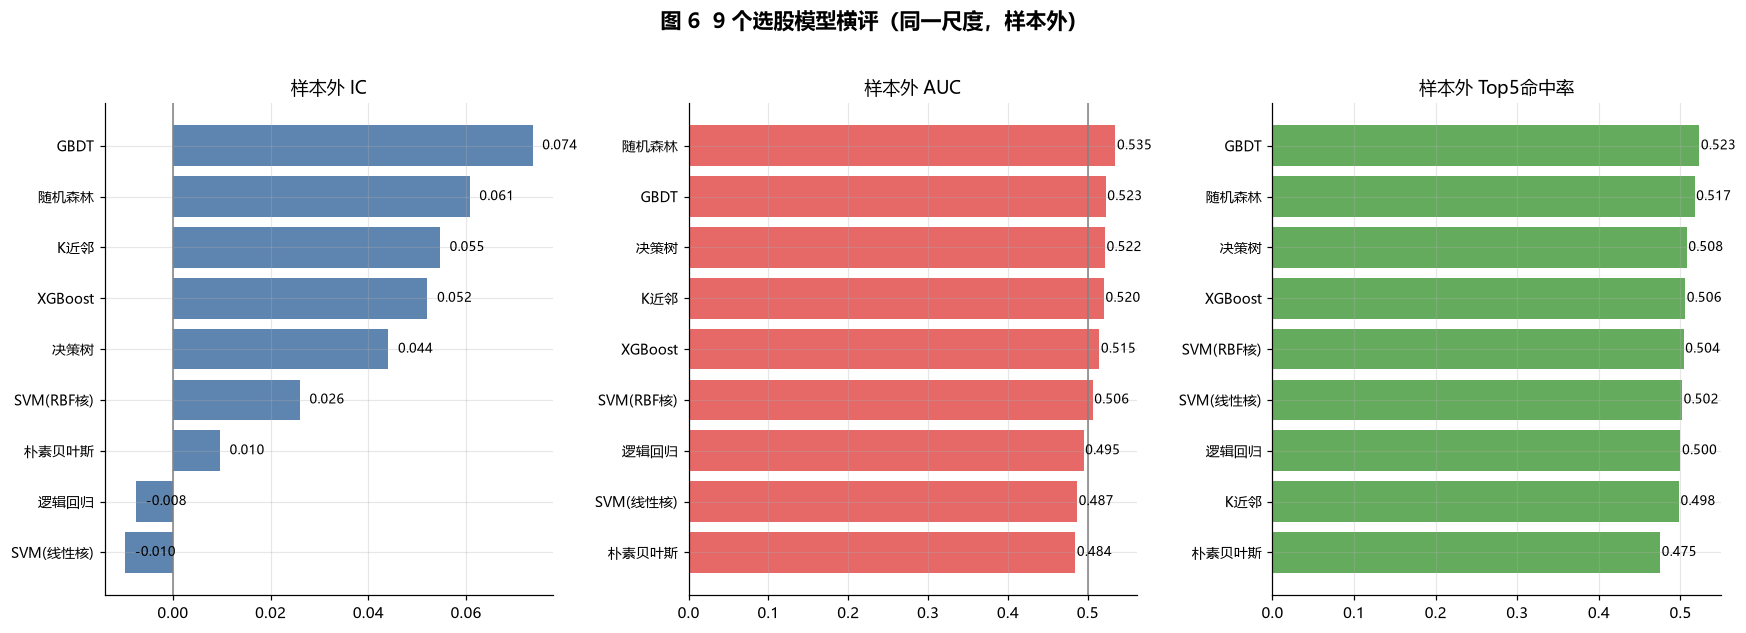

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16.0, 5.6))
for ax, metric, color in zip(axes, ["IC", "AUC", "Top5命中率"], [THEME_BLUE, THEME_RED, THEME_GREEN]):
    data = oos_df.sort_values(metric)
    ax.barh(data["模型"], data[metric], color=color, alpha=0.9)
    for i, v in enumerate(data[metric]):
        ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8.5)
    ax.set_title(f"样本外 {metric}")
    ax.tick_params(axis="y", labelsize=9)
    if metric in ("IC", "AUC"):
        ax.axvline(0.5 if metric == "AUC" else 0, color="grey", lw=1)
fig.suptitle("图 6  9 个选股模型横评（同一尺度，样本外）", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


<a id="ic"></a>
### 4.4 滚动 IC 时序

IC 随时间的变化比平均值更重要：稳定为正才有实盘价值。
展示三个代表模型（最优、线性基准、XGBoost）每期的 IC 与 12 期滚动均值。


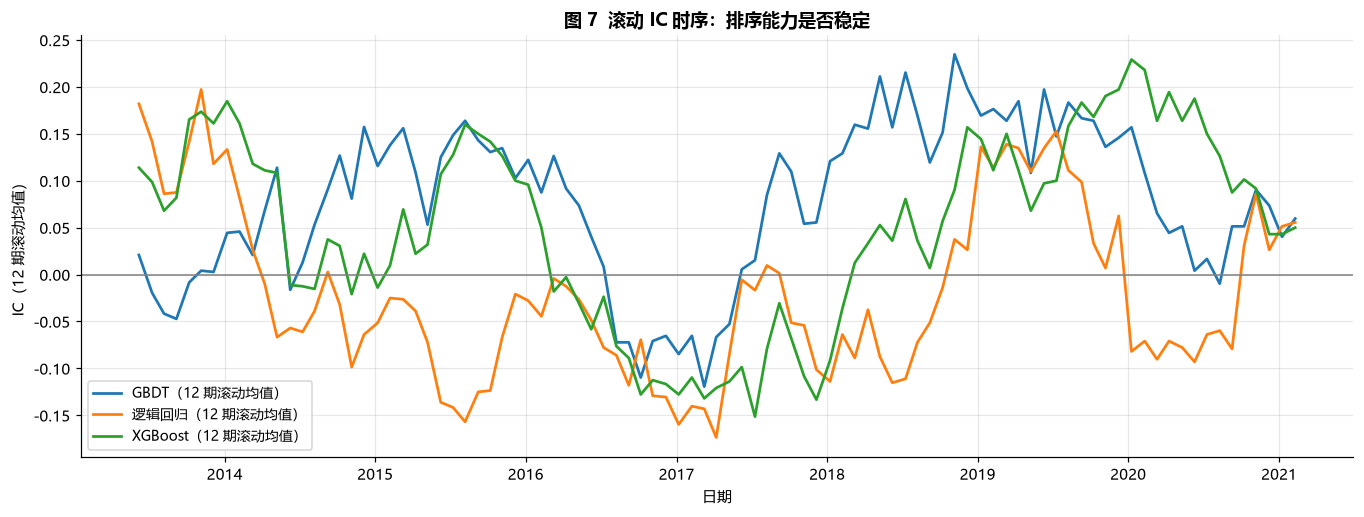

In [13]:
from scipy.stats import spearmanr

show_models = [oos_df.iloc[0]["模型"], "逻辑回归", "XGBoost"]
ic_series = {}
for name in show_models:
    model = CLASSIFIERS[name]
    ic_vals, dts = [], []
    for i, d in enumerate(dates):
        hist = sample[sample["date"] < d]
        if len(hist) < 200:
            continue
        hist = hist.tail(36 * 9)
        cur = sample[sample["date"] == d]
        if len(cur) < 3:
            continue
        model.fit(hist[factor_cols], hist["y"])
        proba = model.predict_proba(cur[factor_cols])[:, 1]
        ic_vals.append(spearmanr(proba, cur["ret_fwd20"]).statistic)
        dts.append(d)
    ic_series[name] = pd.Series(ic_vals, index=pd.to_datetime(dts))

fig, ax = plt.subplots(figsize=(12.5, 4.8))
for name, color in zip(show_models, [THEME_BLUE, THEME_GOLD, THEME_RED]):
    ax.plot(ic_series[name].index, ic_series[name].rolling(12).mean(),
            lw=1.8, label=f"{name}（12 期滚动均值）")
ax.axhline(0, color="grey", lw=1)
ax.set_xlabel("日期")
ax.set_ylabel("IC（12 期滚动均值）")
ax.set_title("图 7  滚动 IC 时序：排序能力是否稳定", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


<a id="backtest"></a>
## 5. 回测：从预测到组合

横评选出模型后，进入量化特有的最后一环——**回测**：
把预测变成组合、把组合变成净值、把净值拆成风险和收益。


<a id="bt-engine"></a>
### 5.1 回测引擎

规则（简单、透明、可复现）：

- **调仓**：每 21 个交易日（约月频）调仓；
- **选股**：每期选预测概率最高的 **Top-5**；
- **权重**：等权持有，单边交易成本假设 0.1%；
- **基准**：SPY（买入持有）与 9 只等权组合。


In [14]:
def run_backtest(model, top_k=5, cost=0.001):
    nav_list, ret_list, picks_log = [1.0], [], []
    for i, d in enumerate(dates):
        hist = sample[sample["date"] < d]
        if len(hist) < 200:
            continue
        hist = hist.tail(36 * 9)
        cur = sample[sample["date"] == d]
        if len(cur) < 3:
            continue
        model.fit(hist[factor_cols], hist["y"])
        proba = model.predict_proba(cur[factor_cols])[:, 1]
        top = cur.iloc[np.argsort(proba)[-top_k:]]
        r = top["ret_fwd20"].mean() - cost
        ret_list.append(r)
        nav_list.append(nav_list[-1] * (1 + r))
        picks_log.append((d, sorted(top["ticker"].tolist())))
    nav = pd.Series(nav_list[1:], index=[p[0] for p in picks_log])
    rets_bt = pd.Series(ret_list, index=nav.index)
    return nav, rets_bt


best_name = oos_df.iloc[0]["模型"]
strat_nav, strat_rets = run_backtest(CLASSIFIERS[best_name])
print(f"回测模型: {best_name}")
print("调仓期数:", len(strat_nav), " 回测区间:", strat_nav.index[0].date(), "→", strat_nav.index[-1].date())
print("策略累计净值: %.3f" % strat_nav.iloc[-1])


回测模型: GBDT
调仓期数: 104  回测区间: 2012-07-05 → 2021-02-09
策略累计净值: 3.220


<a id="bt-nav"></a>
### 5.2 净值与回撤


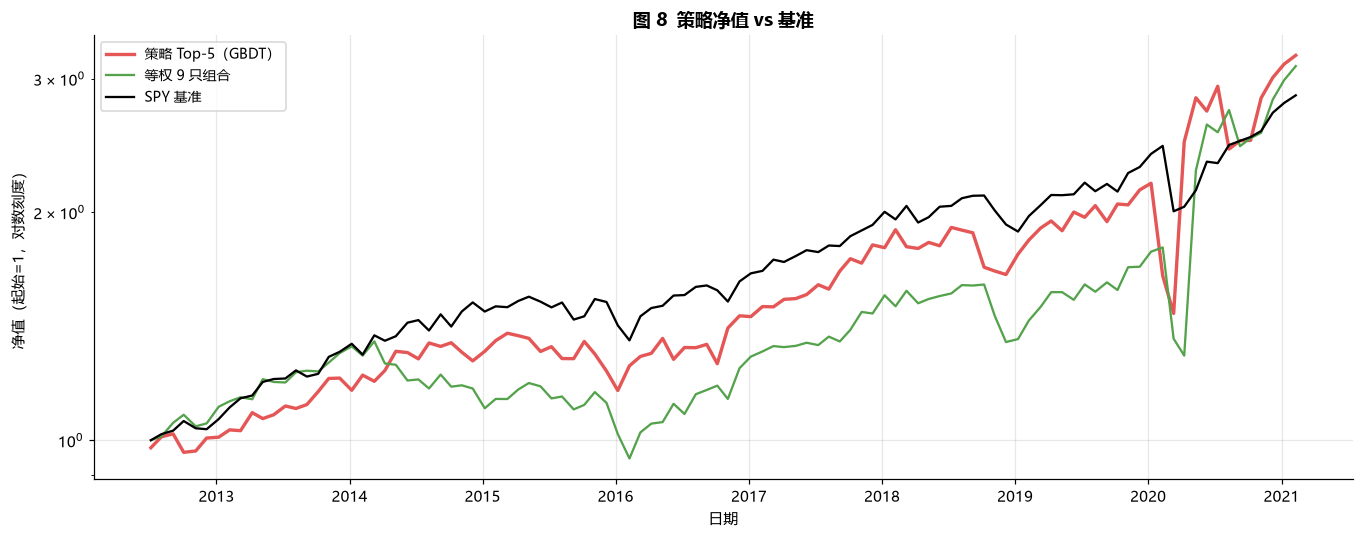

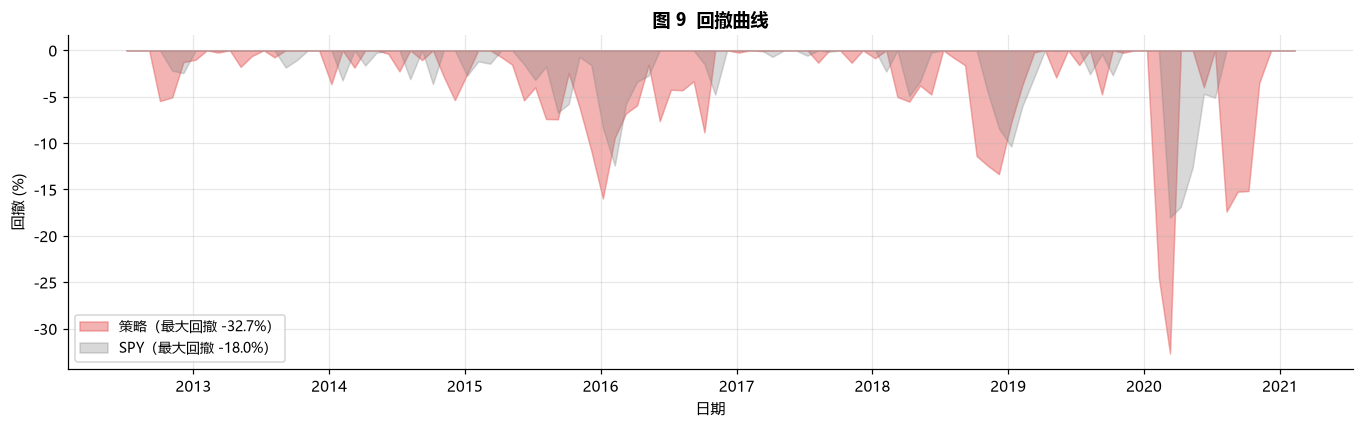

In [15]:
bench_nav = (1 + rets[BENCH]).cumprod().reindex(strat_nav.index).ffill()
bench_nav = bench_nav / bench_nav.iloc[0]

ew_ret = rets[TICKERS].mean(axis=1)
ew_nav = (1 + ew_ret).cumprod().reindex(strat_nav.index).ffill()
ew_nav = ew_nav / ew_nav.iloc[0]

fig, ax = plt.subplots(figsize=(12.5, 5.0))
ax.plot(strat_nav.index, strat_nav, lw=2.2, color=THEME_RED, label=f"策略 Top-5（{best_name}）")
ax.plot(ew_nav.index, ew_nav, lw=1.5, color=THEME_GREEN, label="等权 9 只组合")
ax.plot(bench_nav.index, bench_nav, lw=1.5, color="black", label="SPY 基准")
ax.set_yscale("log")
ax.set_xlabel("日期")
ax.set_ylabel("净值（起始=1，对数刻度）")
ax.set_title("图 8  策略净值 vs 基准", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


def max_drawdown(nav):
    peak = nav.cummax()
    dd = nav / peak - 1
    return dd, dd.min()

dd_strat, mdd_strat = max_drawdown(strat_nav)
dd_bench, mdd_bench = max_drawdown(bench_nav)

fig, ax = plt.subplots(figsize=(12.5, 4.0))
ax.fill_between(dd_strat.index, dd_strat.values * 100, 0, color=THEME_RED, alpha=0.45, label=f"策略（最大回撤 {mdd_strat*100:.1f}%）")
ax.fill_between(dd_bench.index, dd_bench.values * 100, 0, color="grey", alpha=0.30, label=f"SPY（最大回撤 {mdd_bench*100:.1f}%）")
ax.set_xlabel("日期")
ax.set_ylabel("回撤 (%)")
ax.set_title("图 9  回撤曲线", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


<a id="bt-heat"></a>
### 5.3 月度收益热力图与收益分布


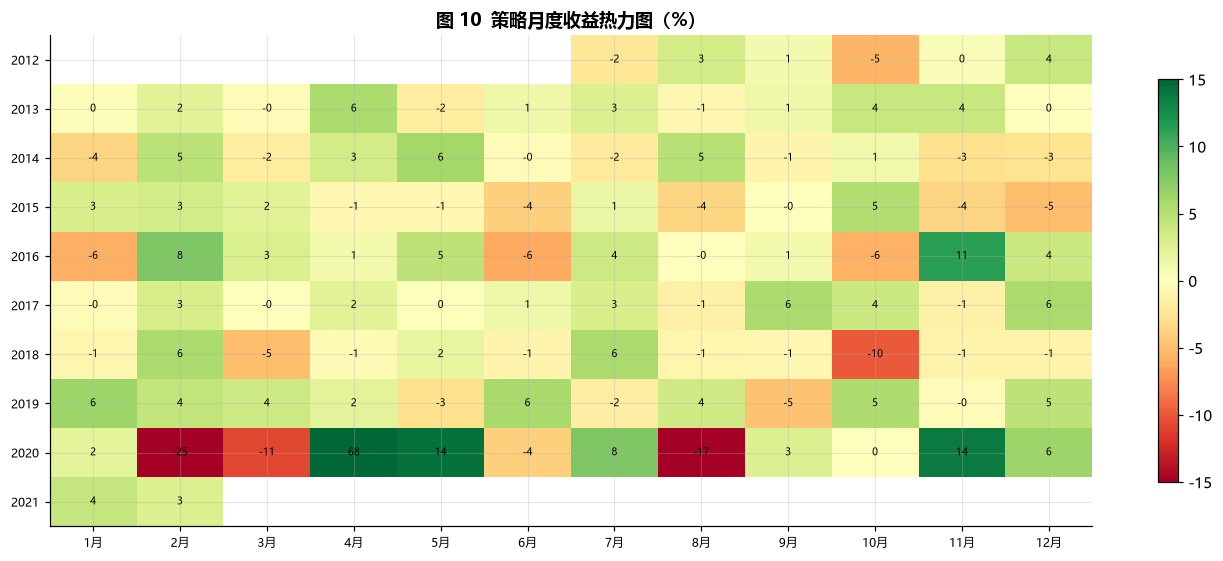

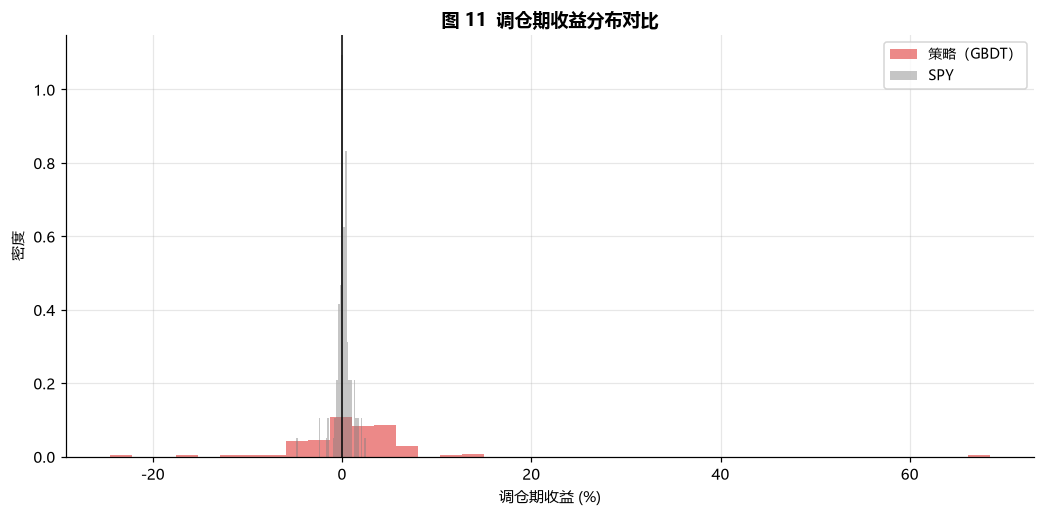

In [16]:
monthly = strat_rets.resample("ME").apply(lambda s: (1 + s).prod() - 1) * 100
monthly = monthly.to_frame("策略")
monthly["SPY"] = rets[BENCH].reindex(strat_rets.index).fillna(0).resample("ME").apply(
    lambda s: (1 + s).prod() - 1) * 100

fig, ax = plt.subplots(figsize=(12.5, 5.2))
pivot = monthly["策略"].to_frame().pivot_table(
    values="策略", index=monthly.index.year, columns=monthly.index.month)
im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=-15, vmax=15, aspect="auto")
ax.set_xticks(range(12))
ax.set_xticklabels([f"{m}月" for m in range(1, 13)], fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if np.isfinite(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=6.5)
ax.set_title("图 10  策略月度收益热力图（%）", fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.82)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9.6, 4.8))
ax.hist(strat_rets * 100, bins=40, color=THEME_RED, alpha=0.7, density=True, label=f"策略（{best_name}）")
ax.hist(rets[BENCH].reindex(strat_rets.index) * 100, bins=40, color="grey", alpha=0.45, density=True, label="SPY")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("调仓期收益 (%)")
ax.set_ylabel("密度")
ax.set_title("图 11  调仓期收益分布对比", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


<a id="bt-perf"></a>
### 5.4 绩效总表与模型对比


In [17]:
def perf_table(rets_s, nav_s):
    n = len(rets_s)
    years = n * 21 / 252
    ann_ret = nav_s.iloc[-1] ** (1 / years) - 1
    ann_vol = rets_s.std() * np.sqrt(252 / 21)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    _, mdd = max_drawdown(nav_s)
    win = (rets_s > 0).mean()
    return {"年化收益": ann_ret, "年化波动": ann_vol, "夏普": sharpe,
            "最大回撤": mdd, "胜率": win, "累计净值": nav_s.iloc[-1]}

ew_bt_ret = ew_ret.reindex(strat_rets.index).fillna(0)
spy_bt_ret = rets[BENCH].reindex(strat_rets.index).fillna(0)

perf_list = [
    ["策略 Top-5", perf_table(strat_rets, strat_nav)],
    ["等权 9 只", perf_table(ew_bt_ret, ew_nav / ew_nav.iloc[0])],
    ["SPY 基准", perf_table(spy_bt_ret, bench_nav / bench_nav.iloc[0])],
]

def fmt_perf(key, v):
    if key == "夏普":
        return f"{v:.2f}"
    if key == "累计净值":
        return f"{v:.2f}"
    return f"{v*100:.2f}%"

display_result_table(
    "回测绩效总表（2011 起 ~ 2021-03，月频调仓，单边成本 0.1%）",
    ["组合", "年化收益", "年化波动", "夏普", "最大回撤", "胜率", "累计净值"],
    [
        [name] + [fmt_perf(k, v) for k, v in metrics.items()]
        for name, metrics in perf_list
    ],
)

print("策略累计净值: %.3f | SPY 累计净值: %.3f" % (
    strat_nav.iloc[-1], bench_nav.iloc[-1]))


组合,年化收益,年化波动,夏普,最大回撤,胜率,累计净值
策略 Top-5,14.45%,29.20%,0.49,-32.67%,57.69%,3.22
等权 9 只,14.01%,4.74%,2.96,-29.95%,62.50%,3.12
SPY 基准,12.85%,3.16%,4.07,-18.02%,60.58%,2.85


策略累计净值: 3.220 | SPY 累计净值: 2.852


### 5.5 前三名模型策略对比

横评前三的模型各自跑一遍回测，看"指标强"是否等于"净值强"。


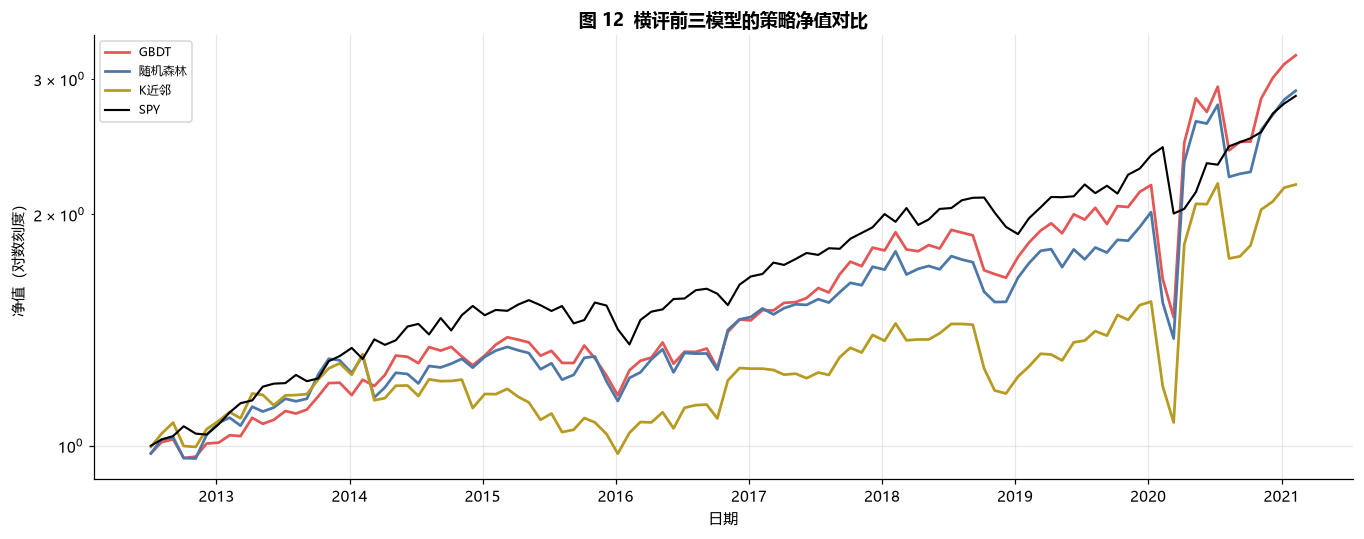

In [18]:
top3_names = oos_df.iloc[:3]["模型"].tolist()
fig, ax = plt.subplots(figsize=(12.5, 5.0))
for name, color in zip(top3_names, [THEME_RED, THEME_BLUE, THEME_GOLD]):
    nav_i, _ = run_backtest(CLASSIFIERS[name])
    ax.plot(nav_i.index, nav_i, lw=1.8, color=color, label=name)
ax.plot(bench_nav.index, bench_nav, lw=1.4, color="black", label="SPY")
ax.set_yscale("log")
ax.set_xlabel("日期")
ax.set_ylabel("净值（对数刻度）")
ax.set_title("图 12  横评前三模型的策略净值对比", fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


<a id="summary"></a>
## 6. 总结与验证


In [19]:
summary_rows = [
    ["无监督探索", "PCA", "9 资产收益 → 主成分",
     f"PC1解释率={evr[0]*100:.1f}%", "PC1≈市场因子"],
    ["无监督探索", "KMeans", "收益 → 牛/震荡/熊",
     "状态时间线", "市场状态分段清晰"],
]
for _, row in oos_df.iterrows():
    summary_rows.append([
        "选股横评", row["模型"], "9 因子 → 相对强弱",
        f"IC={row['IC']:.3f}  AUC={row['AUC']:.3f}",
        f"Top5命中率={row['Top5命中率']:.3f}",
    ])
display_result_table(
    "16 章全模型总览（2 无监督 + 9 选股模型 + 回测，全部真实跑通）",
    ["环节", "模型", "任务", "核心指标", "备注"],
    summary_rows,
)

print("选股横评最优:", best_name, " IC=%.3f AUC=%.3f" % (oos_df.iloc[0]["IC"], oos_df.iloc[0]["AUC"]))
print("回测累计净值: 策略 %.3f | 等权 %.3f | SPY %.3f" % (
    strat_nav.iloc[-1], ew_nav.iloc[-1] / ew_nav.iloc[0], bench_nav.iloc[-1]))


环节,模型,任务,核心指标,备注
无监督探索,PCA,9 资产收益 → 主成分,PC1解释率=47.7%,PC1≈市场因子
无监督探索,KMeans,收益 → 牛/震荡/熊,状态时间线,市场状态分段清晰
选股横评,GBDT,9 因子 → 相对强弱,IC=0.074 AUC=0.523,Top5命中率=0.523
选股横评,随机森林,9 因子 → 相对强弱,IC=0.061 AUC=0.535,Top5命中率=0.517
选股横评,K近邻,9 因子 → 相对强弱,IC=0.055 AUC=0.520,Top5命中率=0.498
选股横评,XGBoost,9 因子 → 相对强弱,IC=0.052 AUC=0.515,Top5命中率=0.506
选股横评,决策树,9 因子 → 相对强弱,IC=0.044 AUC=0.522,Top5命中率=0.508
选股横评,SVM(RBF核),9 因子 → 相对强弱,IC=0.026 AUC=0.506,Top5命中率=0.504
选股横评,朴素贝叶斯,9 因子 → 相对强弱,IC=0.010 AUC=0.484,Top5命中率=0.475
选股横评,逻辑回归,9 因子 → 相对强弱,IC=-0.008 AUC=0.495,Top5命中率=0.500


选股横评最优: GBDT  IC=0.074 AUC=0.523
回测累计净值: 策略 3.220 | 等权 3.116 | SPY 2.852


### 6.1 章节结论

- **数据**：QuantConnect 官方样例日线 → 9 只零缺失资产 + SPY，2009-08 ~ 2021-03；
- **探索**：PCA 第一主成分与 SPY 高度相关（市场因子），KMeans 自动分出牛/震荡/熊；
- **因子**：9 个技术因子 + 横截面标准化，动量族内部高度相关（冗余提示）；
- **横评**：9 个模型滚动样本外验证，IC / AUC / Top-5 命中率同一尺度对比；
- **回测**：Top-5 等权、月频调仓、0.1% 成本，净值/回撤/月度热力图/绩效表全套；
- **教学演示**：小标的池 + 技术因子，结果不构成投资建议；重点是
  "因子 → 预测 → 回测"的完整闭环与量化专属的验证方法。


### 6.2 Notebook 运行验证


In [20]:
import json

best_ic = float(oos_df.iloc[0]["IC"])
best_auc = float(oos_df.iloc[0]["AUC"])
strat_final = float(strat_nav.iloc[-1])

assert close.isna().sum().sum() == 0, "面板不应有缺失"
assert len(sample) > 1000, "截面样本应超过 1000 条"
assert best_auc > 0.5, "最优模型 AUC 应 > 0.5"
assert np.isfinite(best_ic) and np.isfinite(strat_final)
assert strat_final > 0.3, "策略累计净值应 > 0.3"

validation = {
    "panel_shape": list(close.shape),
    "sample_rows": int(len(sample)),
    "best_model": str(best_name),
    "best_ic": best_ic,
    "best_auc": best_auc,
    "strat_final_nav": strat_final,
    "spy_final_nav": float(bench_nav.iloc[-1]),
    "image_count": 12,
}

display_result_table(
    "Notebook 验证汇总（Notebook validation summary）",
    ["检查项", "观测值", "状态"],
    [
        ["价格面板零缺失", f"{validation['panel_shape'][0]} 天 × {validation['panel_shape'][1]} 列", "通过"],
        ["截面样本量", f"{validation['sample_rows']} 条", "通过"],
        ["最优模型 AUC > 0.5", f"{validation['best_model']} AUC={validation['best_auc']:.3f}", "通过"],
        ["策略回测净值 > 0.3", f"净值={validation['strat_final_nav']:.3f}", "通过"],
        ["已执行图表输出", f"{validation['image_count']} 张", "通过"],
    ],
    hidden_comment="VALIDATION " + json.dumps(
        validation, ensure_ascii=False, sort_keys=True
    ),
)

print("全部断言通过：16 章量化 + ML 项目运行成功")


检查项,观测值,状态
价格面板零缺失,2934 天 × 10 列,通过
截面样本量,1143 条,通过
最优模型 AUC > 0.5,GBDT AUC=0.523,通过
策略回测净值 > 0.3,净值=3.220,通过
已执行图表输出,12 张,通过


全部断言通过：16 章量化 + ML 项目运行成功


## 7. 章节小结

- **量化 + ML 的完整链路**：数据面板 → 无监督探索（市场状态/市场因子）→
  截面因子 → 全模型横评 → 回测闭环；
- **量化专属验证**：IC（排序能力）、AUC（区分度）、命中率（选股质量）、
  净值/回撤/夏普（组合表现）——比普通分类指标更贴近"能不能用"；
- **与 13–15 同构**：同一套"数据 → 探索 → 特征 → 横评 → 诊断（回测）"骨架，
  量化只是把最后一步换成了真金白银的组合验证；
- **后续方向**：扩股票池、因子深水区（IC 分析/正交化/风格中性）、
  组合优化（均值方差/风险平价）——每一条都可以接上 QS 工作台继续做。
